# Sales Analysis

This notebook reviews 1,000 European product orders from 2019–2020 and asks whether **net sales** (order value minus cost of goods) can be predicted from attributes you would know without seeing the invoice totals.

**Data.** `Sales-Export_2019-2020.csv` includes country, order value, cost, product category, customer, sales manager, sales representative, device type, and order id.

**Approach.**
1. Clean headers and convert currency fields to numbers
2. Engineer `net_sales` and explore distributions
3. Train Linear Regression, Huber Regression, and XGBoost on categorical features only: country, category, sales manager, sales rep, and device type
4. Forecast monthly net sales with a hand-specified ARIMA and `pmdarima`'s `auto_arima`

**Columns left out of the models.** `sales_EUR` and `cogs` define the target (`net_sales = sales_EUR - cogs`), so using them would give a perfect but meaningless fit. `order_id` and `customer_name` are identifiers, not drivers of profit.

In [125]:
# Data wrangling and plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and models
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import streamlit as st

## Data loading and cleaning

Inspect the raw export, fix column names, and convert currency and id fields to numeric types.

In [126]:
# First look at the raw export. Several headers have leading spaces.
sales_data = pd.read_csv('Sales-Export_2019-2020.csv', index_col= 'date', parse_dates = True)
sales_data.head()

,country,order_value_EUR,cost,category,customer_name,sales_manager,sales_rep,device_type,order_id
date,,,,,,,,,
2020-02-12,Sweden,"17,524.02",14122.61,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
2019-09-26,Finland,"116,563.40",92807.78,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2019-07-11,Portugal,"296,465.56",257480.34,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
2020-04-02,Portugal,"74,532.02",59752.32,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
2019-12-22,Spain,"178,763.42",146621.76,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


In [127]:
# Only `cost` is numeric in the raw file, so this summary is limited.
sales_data.describe()

,cost
count,1000.000000
mean,94369.310990
std,51540.020934
min,12113.680000
25%,54247.957500
50%,87094.760000
75%,125570.837500
max,304701.430000


In [128]:
# order_value_EUR is a string because values include thousands separators.
sales_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1000 entries, 2020-02-12 to 2020-01-18
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            1000 non-null   str    
 1    order_value_EUR   1000 non-null   str    
 2    cost              1000 non-null   float64
 3   category           1000 non-null   str    
 4   customer_name      1000 non-null   str    
 5   sales_manager      1000 non-null   str    
 6   sales_rep          1000 non-null   str    
 7   device_type        1000 non-null   str    
 8   order_id           1000 non-null   str    
dtypes: float64(1), str(8)
memory usage: 158.9 KB


In [129]:
# Total missing values in the raw frame
sales_data.isnull().sum().sum()

np.int64(0)

In [130]:
# Reload, strip header whitespace, and rename fields used later
sales_data = pd.read_csv('Sales-Export_2019-2020.csv', index_col='date', parse_dates=True)
sales_data.columns = sales_data.columns.str.strip()
sales_data = sales_data.rename(columns={
    "order_value_EUR": "sales_EUR",
    "cost": "cogs",
})
sales_data.columns

Index(['country', 'sales_EUR', 'cogs', 'category', 'customer_name',
       'sales_manager', 'sales_rep', 'device_type', 'order_id'],
      dtype='str')

In [131]:
# sales_EUR still contains comma-formatted strings such as "17,524.02"
sales_data.head()

,country,sales_EUR,cogs,category,customer_name,sales_manager,sales_rep,device_type,order_id
date,,,,,,,,,
2020-02-12,Sweden,"17,524.02",14122.61,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
2019-09-26,Finland,"116,563.40",92807.78,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2019-07-11,Portugal,"296,465.56",257480.34,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
2020-04-02,Portugal,"74,532.02",59752.32,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
2019-12-22,Spain,"178,763.42",146621.76,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


In [132]:
# Convert sales to float in place (commas would keep the column as text)
sales_data['sales_EUR'] = (
    sales_data['sales_EUR']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)
sales_data.head()

,country,sales_EUR,cogs,category,customer_name,sales_manager,sales_rep,device_type,order_id
date,,,,,,,,,
2020-02-12,Sweden,17524.02,14122.61,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
2019-09-26,Finland,116563.40,92807.78,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2019-07-11,Portugal,296465.56,257480.34,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
2020-04-02,Portugal,74532.02,59752.32,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
2019-12-22,Spain,178763.42,146621.76,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


In [133]:
# Remove hyphens so order_id can be stored as an integer
sales_data['order_id'] = (
    sales_data['order_id']
    .astype(str)
    .str.replace('-', '', regex = False)
    .astype(int)
)
sales_data.head()

,country,sales_EUR,cogs,category,customer_name,sales_manager,sales_rep,device_type,order_id
date,,,,,,,,,
2020-02-12,Sweden,17524.02,14122.61,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,700511466
2019-09-26,Finland,116563.40,92807.78,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,286585323
2019-07-11,Portugal,296465.56,257480.34,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,587703341
2020-04-02,Portugal,74532.02,59752.32,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,146700183
2019-12-22,Spain,178763.42,146621.76,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,158765160


In [134]:
# Confirm sales_EUR is float64 after the cleanup
sales_data.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 1000 entries, 2020-02-12 to 2020-01-18
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1000 non-null   str    
 1   sales_EUR      1000 non-null   float64
 2   cogs           1000 non-null   float64
 3   category       1000 non-null   str    
 4   customer_name  1000 non-null   str    
 5   sales_manager  1000 non-null   str    
 6   sales_rep      1000 non-null   str    
 7   device_type    1000 non-null   str    
 8   order_id       1000 non-null   int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 139.9 KB


In [135]:
# Target: profit per order. pct_change is for EDA only, not for modeling.
sales_data['net_sales'] = sales_data['sales_EUR'] - sales_data['cogs']
sales_data['pct_change'] = sales_data['net_sales'].pct_change()
sales_data.head()

,country,sales_EUR,cogs,category,customer_name,sales_manager,sales_rep,device_type,order_id,net_sales,pct_change
date,,,,,,,,,,,
2020-02-12,Sweden,17524.02,14122.61,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,700511466,3401.41,NaN
2019-09-26,Finland,116563.40,92807.78,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,286585323,23755.62,5.984051
2019-07-11,Portugal,296465.56,257480.34,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,587703341,38985.22,0.641095
2020-04-02,Portugal,74532.02,59752.32,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,146700183,14779.70,-0.620890
2019-12-22,Spain,178763.42,146621.76,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,158765160,32141.66,1.174717


In [136]:
# Keep a stable column order for the rest of the notebook
sales_data = sales_data[[
    'country',
    'sales_EUR',
    'cogs',
    'net_sales',
    'pct_change',
    'category',
    'customer_name',
    'sales_manager',
    'sales_rep',
    'device_type',
    'order_id',
]]
sales_data.head()

,country,sales_EUR,cogs,net_sales,pct_change,category,customer_name,sales_manager,sales_rep,device_type,order_id
date,,,,,,,,,,,
2020-02-12,Sweden,17524.02,14122.61,3401.41,NaN,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,700511466
2019-09-26,Finland,116563.40,92807.78,23755.62,5.984051,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,286585323
2019-07-11,Portugal,296465.56,257480.34,38985.22,0.641095,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,587703341
2020-04-02,Portugal,74532.02,59752.32,14779.70,-0.620890,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,146700183
2019-12-22,Spain,178763.42,146621.76,32141.66,1.174717,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,158765160


## Exploratory analysis

Check the shape of sales and cost, and how net sales change by country.

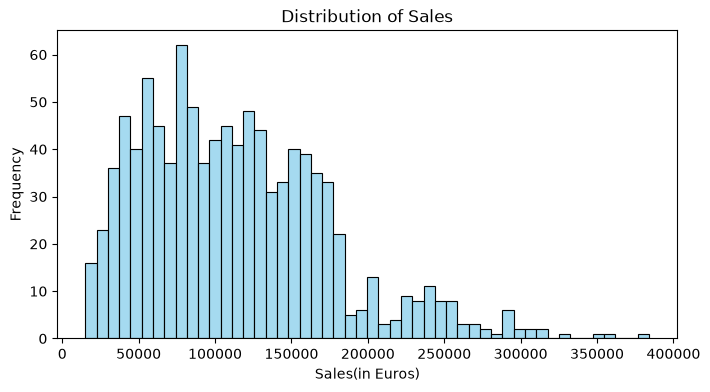

In [137]:
# Sales are right-skewed: most orders sit below ~€150k, with a long upper tail
plt.figure(figsize = (8, 4))
sns.histplot(sales_data['sales_EUR'], 
            bins = 50,
            color = 'skyblue',
            edgecolor = 'black')
plt.title('Distribution of Sales')
plt.xlabel('Sales(in Euros)')
plt.ylabel('Frequency')
plt.show()

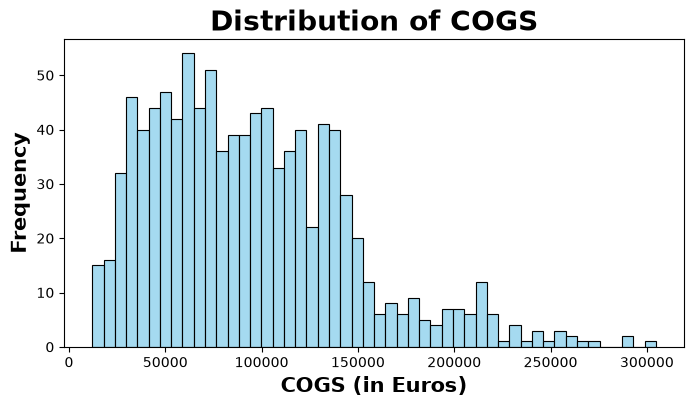

In [138]:
# COGS follows the same shape as sales, which is expected if margins are fairly stable
plt.figure(figsize = (8, 4))
sns.histplot(sales_data['cogs'], 
             bins = 50,
             color = 'skyblue',
             edgecolor = 'black')
plt.title('Distribution of COGS', fontsize = 20, fontweight = 'bold')
plt.xlabel('COGS (in Euros)', fontsize = 15, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 15, fontweight = 'bold')
plt.show()

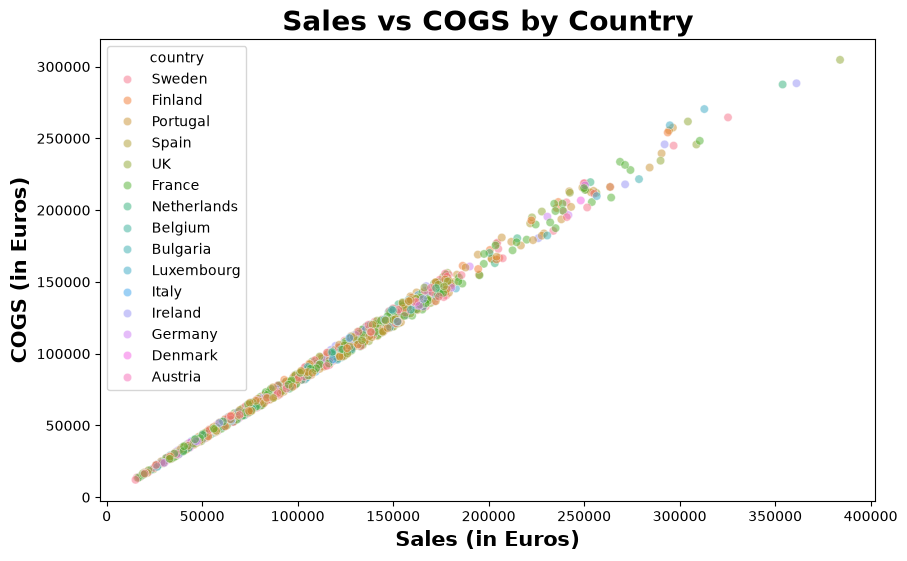

In [139]:
# Sales and COGS move together almost linearly; country does not break that pattern
plt.figure(figsize = (10, 6))
sns.scatterplot(x = 'sales_EUR',
                y = 'cogs',
                data = sales_data,
                hue = 'country',
                alpha = 0.5
                )
plt.title("Sales vs COGS by Country", fontsize = 20, fontweight = 'bold')
plt.xlabel('Sales (in Euros)', fontsize = 15, fontweight = 'bold')
plt.ylabel('COGS (in Euros)', fontsize = 15, fontweight = 'bold')
plt.show()

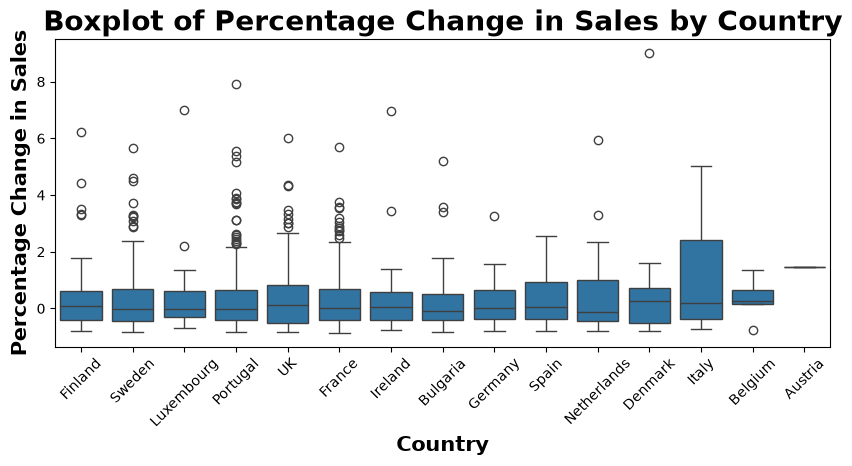

In [140]:
# Sort by date, then look at period-to-period net-sales change within each country
sales_data = sales_data.sort_index()
sales_data['pct_change'] = sales_data.groupby('country')['net_sales'].pct_change()

plt.figure(figsize=(10, 4))
sns.boxplot(
    data=sales_data.reset_index(),
    x='country',
    y='pct_change',
)
plt.xticks(rotation = 45)
plt.title('Boxplot of Percentage Change in Sales by Country', fontsize=20, fontweight='bold')
plt.xlabel('Country', fontsize=15, fontweight='bold')
plt.ylabel('Percentage Change in Sales', fontsize=15, fontweight='bold')
plt.show()

## Regression setup

Copy the cleaned data, drop leakage and identifier columns, then build a shared preprocessing pipeline.

In [141]:
# Modeling copy. The first pct_change in each country is NaN; fill those with 0.
sales_data_regression = sales_data.copy()

sales_data_regression.fillna(0, inplace = True)
sales_data_regression.isna().sum().sum()

np.int64(0)

In [142]:
# Drop leakage (sales, cogs, pct_change) and IDs. Assign the result or the drop is lost.
sales_data_regression = sales_data_regression.drop(columns=[
    'sales_EUR',
    'cogs',
    'pct_change',
    'order_id',
    'customer_name',
])
sales_data_regression.head()

,country,net_sales,category,sales_manager,sales_rep,device_type
date,,,,,,
2019-01-02,Finland,25404.55,Games,Hube Corey,Mellicent Mattys,PC
2019-01-02,Sweden,22861.24,Appliances,Maxie Marrow,Tarrah Castelletti,PC
2019-01-02,Luxembourg,11610.33,Electronics,Ilsa Kob,Jocelyn Laurentino,PC
2019-01-02,Portugal,25429.46,Appliances,Celine Tumasian,Smitty Culverhouse,Mobile
2019-01-05,Portugal,22762.62,Smartphones,Celine Tumasian,Hortense Gerring,PC


In [143]:
# Modeling frame should now be net_sales plus categorical attributes only
sales_data_regression.head()

,country,net_sales,category,sales_manager,sales_rep,device_type
date,,,,,,
2019-01-02,Finland,25404.55,Games,Hube Corey,Mellicent Mattys,PC
2019-01-02,Sweden,22861.24,Appliances,Maxie Marrow,Tarrah Castelletti,PC
2019-01-02,Luxembourg,11610.33,Electronics,Ilsa Kob,Jocelyn Laurentino,PC
2019-01-02,Portugal,25429.46,Appliances,Celine Tumasian,Smitty Culverhouse,Mobile
2019-01-05,Portugal,22762.62,Smartphones,Celine Tumasian,Hortense Gerring,PC


In [144]:
# After the drop, X is all categorical. These lists still drive the ColumnTransformer.
X = sales_data_regression.drop(columns = ['net_sales'])
y = sales_data_regression['net_sales']

numeric_features = X.select_dtypes(include = ['int64', 'float64']).columns
categoric_features = X.select_dtypes(include = ['object', 'str', 'category', 'bool']).columns

In [ ]:
# Numeric: fill missing values, then standardize.
# Categoric: fill missing values, then one-hot encode.
# handle_unknown='ignore' encodes unseen test categories as all zeros.
# Do not pair that setting with drop='first' — sklearn will warn and the
# dropped baseline becomes indistinguishable from an unknown category.
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])
categoric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output = False)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categoric', categoric_pipeline, categoric_features),
])

## Linear regression

Fit OLS on the held-out 20% of orders, then rank coefficients by absolute size.

In [146]:
# Ordinary least squares. Hold out 20% of orders for a clean test score.
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
X_train, X_test, y_train, y_test = train_test_split(
                                                    X, 
                                                    y, 
                                                    test_size = 0.2,
                                                    random_state = 42)
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# R² < 0 means the model loses to predicting the mean net sale
print(f"R-squared: {r2_score(y_test, y_pred_linear):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_linear):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_linear):.4f}")

R-squared: -0.0300
MAE: 8288.3043
MSE: 106823995.2299


In [147]:
# Align one-hot feature names with LinearRegression.coef_ and rank by |effect|
feature_names = linear_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = linear_model.named_steps['regressor'].coef_

coefficient_table = (
    pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
    })
    .sort_values('Coefficient', key=abs, ascending=False)
)

coefficient_table

,Feature,Coefficient
50,categoric__sales_rep_Cobby Andersen,-4652.474026
66,categoric__sales_rep_Perri Aldersley,-4117.013295
43,categoric__sales_rep_Bernadine Fullagar,3006.670423
52,categoric__sales_rep_Corene Shirer,2936.876656
48,categoric__sales_rep_Case Desorts,2557.131551
...,...,...
39,categoric__sales_rep_Amelina Piscopiello,207.003566
70,categoric__sales_rep_Wat Bowkley,204.215414
55,categoric__sales_rep_Hortense Gerring,-62.266983
38,categoric__sales_rep_Alyosha Meah,39.873324


## Huber regression

Same features and split as the linear model. Huber is more robust to the long right tail in order size.

In [148]:
# Optional Huber-specific pipes. The ColumnTransformer below still uses the
# shared numeric/categoric pipelines, so drop='first' here is unused.
numeric_pipelineHr = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])
categoric_pipelineHr = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',
                             drop = 'first',
                             sparse_output = False)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categoric', categoric_pipeline, categoric_features),
])

In [149]:
# Huber uses a linear loss for large residuals, so outliers pull less than in OLS
huber_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', HuberRegressor(max_iter = 1000))
])
huber_model.fit(X_train, y_train)
y_pred_huber = huber_model.predict(X_test)

print(f"R-squared: {r2_score(y_test, y_pred_huber):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_huber):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_huber):.4f}")

R-squared: -0.0217
MAE: 8120.3965
MSE: 105965876.7948


## XGBoost

Same features and split as Linear and Huber. String columns are one-hot encoded first because XGBoost cannot take raw text.

In [150]:
# XGBoost cannot take raw string columns. Reuse the shared preprocessor
# (one-hot encode categoricals) and the same train/test split as the other models.
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
    )),
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"R-squared: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.4f}")

R-squared: -0.1339
MAE: 8460.6912
MSE: 117607564.3808


## Forecast comparison

Actual test-set net sales versus the Linear, Huber, and XGBoost predictions. Points on the dashed line would be perfect forecasts.

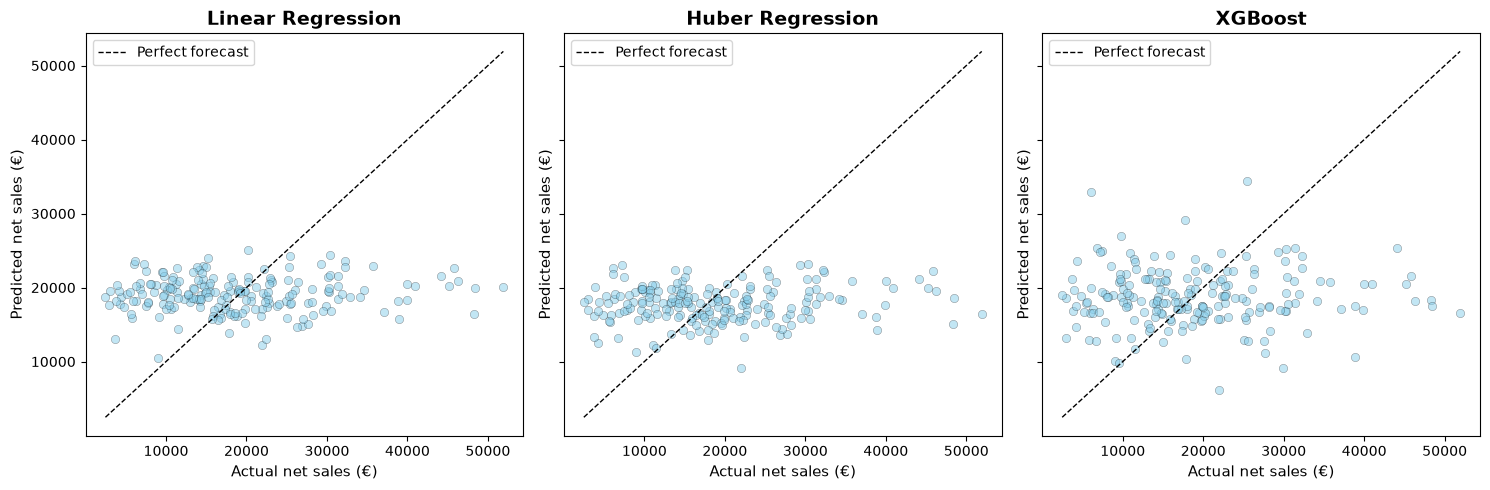

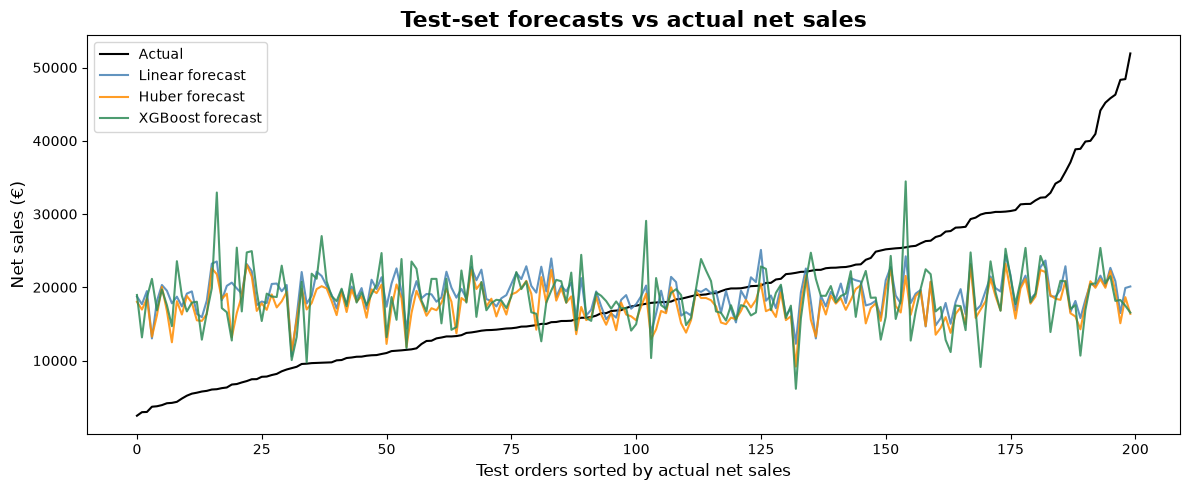

In [151]:
# Compare all three models on the same held-out orders
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
min_val = min(y_test.min(), y_pred_linear.min(), y_pred_huber.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_linear.max(), y_pred_huber.max(), y_pred_xgb.max())

for ax, preds, title in [
    (axes[0], y_pred_linear, 'Linear Regression'),
    (axes[1], y_pred_huber, 'Huber Regression'),
    (axes[2], y_pred_xgb, 'XGBoost'),
]:
    ax.scatter(y_test, preds, alpha=0.5, color='skyblue', edgecolor='black', linewidth=0.3)
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label='Perfect forecast')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Actual net sales (€)', fontsize=11)
    ax.set_ylabel('Predicted net sales (€)', fontsize=11)
    ax.legend()

plt.tight_layout()
plt.show()

# Overlay forecasts after sorting the test set by actual net sales
forecasts = pd.DataFrame({
    'actual': y_test.to_numpy(),
    'linear': y_pred_linear,
    'huber': y_pred_huber,
    'xgboost': y_pred_xgb,
}).sort_values('actual').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(forecasts['actual'], label='Actual', color='black', linewidth=1.5)
plt.plot(forecasts['linear'], label='Linear forecast', color='steelblue', alpha=0.85)
plt.plot(forecasts['huber'], label='Huber forecast', color='darkorange', alpha=0.85)
plt.plot(forecasts['xgboost'], label='XGBoost forecast', color='seagreen', alpha=0.85)
plt.title('Test-set forecasts vs actual net sales', fontsize=16, fontweight='bold')
plt.xlabel('Test orders sorted by actual net sales', fontsize=12)
plt.ylabel('Net sales (€)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Chart summary

**Actual vs predicted (scatter).** A useful forecast would hug the dashed diagonal. All three panels form a flat cloud: predicted net sales stay in a narrow band while actuals run from a few thousand to well over €40k. That is visual confirmation of the negative R² — none of the models track individual orders.

**Forecast overlay (line chart).** After sorting the 200 test orders by actual net sales, the black actual line rises from the smallest to the largest orders. Linear (blue), Huber (orange), and XGBoost (green) do not climb with it. They oscillate around the average, so low-profit orders are over-predicted and high-profit orders are under-predicted.

**Linear vs Huber vs XGBoost.** Linear and Huber stay close, with Huber a bit lower on the largest orders. XGBoost wiggles more — it overfits small groups of sales reps and categories in the training set — and its test forecasts are the noisiest of the three. None of the lines follow the actuals.

## Summary of regression results

All three models predict `net_sales` from country, category, sales manager, sales rep, and device type only. The same 80/20 split and random seed are used so the scores are comparable.

| Model | R² | MAE (€) | MSE |
|---|---|---|---|
| Linear Regression | −0.0300 | 8,288 | 1.07 × 10⁸ |
| Huber Regression | −0.0217 | 8,120 | 1.06 × 10⁸ |
| XGBoost | −0.1339 | 8,461 | 1.18 × 10⁸ |

**Linear Regression.** Ordinary least squares is slightly worse than predicting the average test-set net sale (~€18,800). An MAE of about €8,300 on a typical order of that size means the categorical attributes are not locating profit. The largest coefficients attach to individual sales reps and a few product categories, but those effects do not hold up out of sample — high-cardinality dummies overfit small groups.

**Huber Regression.** Huber down-weights large residuals, so a handful of extreme orders move the fit less than they do in OLS. That shows up as a slightly better MAE and R². The improvement is small. The model is still worse than a mean baseline.

**XGBoost.** Trees can fit interactions the linear models miss, but here that extra flexibility overfits the training categories. Test R² and MAE are worse than both Linear and Huber. On the overlay, the green line is the most jagged and still does not follow actual net sales.

**What the charts show.** In the scatter plots, points would need to lie on the dashed diagonal to be accurate. All three models produce a horizontal band of predictions instead. In the overlay, actual net sales rise across the sorted test set while Linear, Huber, and XGBoost stay near the mean — over-forecasting small orders and under-forecasting large ones. XGBoost moves more than the other two; it does not move in the right direction.

**Takeaway.** Country, category, device, manager, and rep do not contain a usable signal for net sales in this sample, even with a non-linear model. A better model would need features that actually vary with margin — discounting, product mix, or order size — rather than identity fields. Using `sales_EUR` or `cogs` as predictors would drive error to zero, but only because those columns *define* the target.

## ARIMA forecast

The raw order index cannot be used: dates repeat and are not evenly spaced. Monthly totals give ARIMA a regular frequency.

2020-10-01    511062.589185
2020-11-01    459772.756910
2020-12-01    859704.473597
Freq: MS, Name: predicted_mean, dtype: float64
MAE: 255875.91
RMSE: 275597.17


/Users/michaelperrine/Documents/sales-analysis/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/michaelperrine/Documents/sales-analysis/.venv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


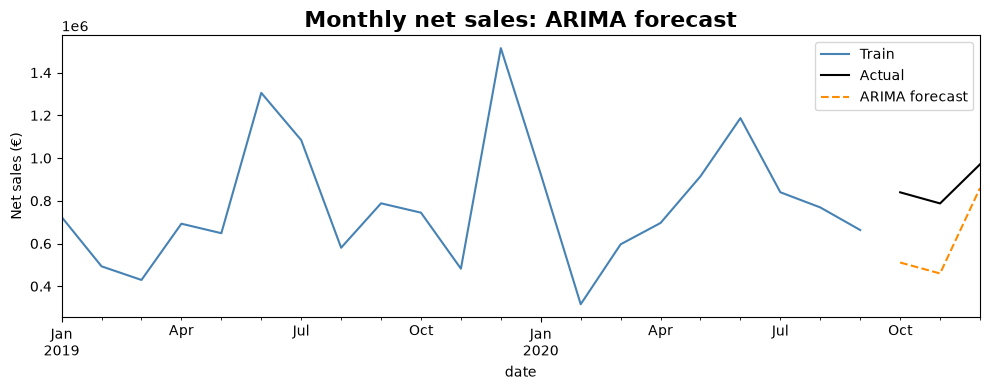

In [153]:
# Order dates are irregular and many days have multiple orders, so the index
# has no frequency. ARIMA needs a regular series — resample to monthly totals.
monthly_net_sales = (
    sales_data['net_sales']
    .resample('MS')
    .sum()
    .asfreq('MS')
)

# Hold out the last 3 months (Oct–Dec 2020) to score the forecast.
# 21 training months is short for seasonal_order period 12.
monthly_train = monthly_net_sales.iloc[:-3]
monthly_test = monthly_net_sales.iloc[-3:]

arima_model = ARIMA(
    monthly_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
)
arima_results = arima_model.fit()
arima_forecast = arima_results.forecast(steps=len(monthly_test))

print(arima_forecast)
print(f"MAE: {mean_absolute_error(monthly_test, arima_forecast):.2f}")
print(f"RMSE: {mean_squared_error(monthly_test, arima_forecast) ** 0.5:.2f}")

plt.figure(figsize=(10, 4))
monthly_train.plot(label='Train', color='steelblue')
monthly_test.plot(label='Actual', color='black')
arima_forecast.plot(label='ARIMA forecast', color='darkorange', style='--')
plt.title('Monthly net sales: ARIMA forecast', fontsize=16, fontweight='bold')
plt.ylabel('Net sales (€)')
plt.legend()
plt.tight_layout()
plt.show()

### ARIMA chart summary

**What the plot shows.** Monthly net sales from 2019 through September 2020 are the training series. The last three months (Oct–Dec 2020) are held out. The dashed orange line is the forecast from a hand-specified SARIMA `(1,1,1)(1,1,1,12)`.

**How it scores.** Actual monthly totals are about €840k, €788k, and €971k. The model forecasts €511k, €460k, and €860k. MAE is €255,876 and RMSE is €275,597 — large relative to a typical month of ~€600–900k.

**Why the fit is fragile.** Statsmodels warns that 21 months is too short to estimate seasonal ARMA starting values. The `(1,1,1,12)` seasonal piece is under-identified. The forecast follows the level of the series but misses the late-2020 rebound.

## pmdarima auto_arima

`auto_arima` searches (p, d, q) and seasonal (P, D, Q, 12) on the same monthly train/test split. With only 21 training months the search is kept small.

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=247.384, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=250.897, Time=0.01 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=250.445, Time=0.02 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=249.846, Time=0.00 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=249.111, Time=0.02 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=249.099, Time=0.01 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=249.580, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=249.085, Time=0.01 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=248.321, Time=0.02 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 0.125 seconds
                                SARIMAX Results                                 
Dep. Variable:                        y   No. Observations:                   21
Model:             SARIMAX(0, 1, 0, 12)   Log Likelihood     

/Users/michaelperrine/Documents/sales-analysis/.venv/lib/python3.13/site-packages/pmdarima/arima/utils.py:117: UserWarning: Appropriate D value may not have been reached; length of seasonally-differenced array (9) is shorter than m (12). Using D=1
  warnings.warn("Appropriate D value may not have been reached; "


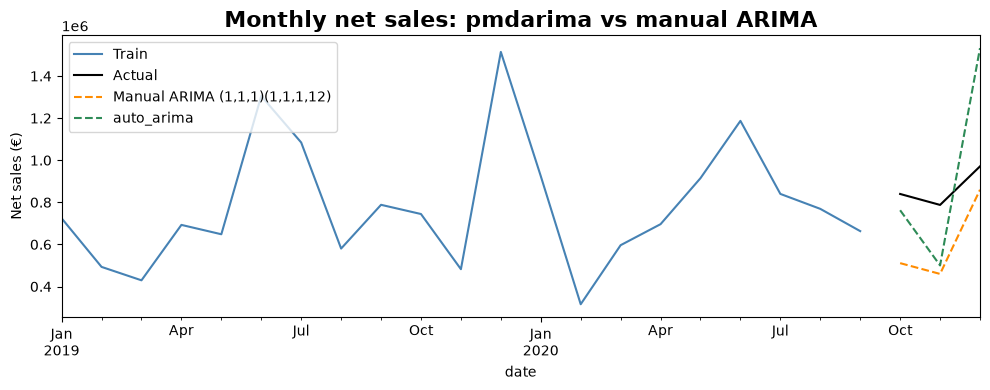

In [ ]:
# Search ARIMA/SARIMA orders by AIC on the monthly training window.
# m=12 is yearly seasonality. max_p/q stay small because 21 months is a short sample.
auto_arima_model = auto_arima(
                                monthly_train,
                                start_p=0,
                                start_q=0,
                                max_p=2,
                                max_q=2,
                                d=None,
                                start_P=0,
                                start_Q=0,
                                max_P=1,
                                max_Q=1,
                                D=None,
                                m=12,
                                seasonal=True,
                                stepwise=True,
                                suppress_warnings=True,
                                error_action='ignore',
                                trace=True,
                            )

print(auto_arima_model.summary())
print(f"Selected order: {auto_arima_model.order}")
print(f"Selected seasonal order: {auto_arima_model.seasonal_order}")

# Forecast the same 3-month holdout and align it to the monthly index
auto_arima_forecast = auto_arima_model.predict(n_periods=len(monthly_test))
auto_arima_forecast = pd.Series(auto_arima_forecast, index=monthly_test.index, name='auto_arima')

print(auto_arima_forecast)
print(f"MAE: {mean_absolute_error(monthly_test, auto_arima_forecast):.2f}")
print(f"RMSE: {mean_squared_error(monthly_test, auto_arima_forecast) ** 0.5:.2f}")

plt.figure(figsize=(10, 4))
monthly_train.plot(label='Train', color='steelblue')
monthly_test.plot(label='Actual', color='black')
arima_forecast.plot(label='Manual ARIMA (1,1,1)(1,1,1,12)', color='darkorange', style='--')
auto_arima_forecast.plot(label='auto_arima', color='seagreen', style='--')
plt.title('Monthly net sales: pmdarima vs manual ARIMA', fontsize=16, fontweight='bold')
plt.ylabel('Net sales (€)')
plt.legend()
plt.tight_layout()
plt.show()

### auto_arima chart summary

**What the plot shows.** The same monthly train/test split, with `auto_arima` (green) next to the manual SARIMA (orange). `auto_arima` selected **`(0,0,0)(0,1,0,12)` with intercept** — last year’s same month plus a small drift.

**How it scores.** Forecasts are about €762k, €500k, and €1.53m versus actuals of €840k, €788k, and €971k. MAE is €308,876 and RMSE is €367,072, worse than the hand-specified ARIMA on this holdout.

**How to read the search.** AIC prefers the simplest seasonal difference because there are only 9 seasonally differenced points, fewer than `m=12`. That is why richer ARMA terms lose. The December spike in the green line is last December plus drift, not a learned holiday effect.

## Summary of time series results

Both forecasts use **monthly total net sales** (24 months, 2019–2020). The last 3 months are the test window. Order-level dates cannot be used: they repeat and have no regular frequency.

| Model | Selected order | MAE (€) | RMSE (€) |
|---|---|---|---|
| Manual ARIMA | (1, 1, 1)(1, 1, 1, 12) | 255,876 | 275,597 |
| auto_arima | (0, 0, 0)(0, 1, 0, 12) + intercept | 308,876 | 367,072 |

**Manual ARIMA.** A full seasonal specification on 21 training months. It under-forecasts Oct and Nov and comes closer in Dec. Statsmodels warns that seasonal starting values cannot be estimated. The extra ARMA terms are not well supported by the sample.

**auto_arima.** AIC picks a seasonal random walk with drift: this month ≈ the same month last year + ~€18k. That is the honest model given the short history. It is closer in October, worse in November, and overshoots December by about €560k.

**What the charts show.** Neither dashed line tracks the late-2020 rise. Monthly net sales jump around too much, and one year of seasonality is not enough to pin down a December effect.

**Takeaway.** Time-series models here forecast the **month total**, not individual orders. They are a different question from the regressions. With only two years of data, prefer the simpler `auto_arima` specification for interpretation, and treat any 12-month seasonal ARMA as fragile. A useful next step would be a longer history or weekly totals with more observations per season.